#  Introduction

**Dataset:**  
This dataset contains information about Netflix titles including movies and TV shows available on the platform.

**Interest:**  
I chose this dataset because the name *“Netflix ”* was catchy , sparked my curiosityand we found it a cool dataset to work with .

**Source:**  
Netflix Dataset on Kaggle (https://www.kaggle.com/datasets/shivamb/netflix-shows)

**Records:**  
It has **8,807** entries.

**Columns:**

- **show_id:** Unique ID  
- **type:** Movie or TV Show  
- **title:** Name of the content  
- **director:** Director of the content  
- **cast:** Actors  
- **country:** Country of origin  
- **date_added:** Date added to Netflix  
- **release_year:** Release year  
- **rating:** Content rating  
- **duration:** Duration (minutes or seasons)  
- **listed_in:** Genres  
- **description:** Short synopsis

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [99]:
df = pd.read_csv("netflix_titles.csv")

In [100]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


as we can see here .. director,cast,country,date_added,release_year,rating and duration have null values

In [103]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


Desscribing  the Release Years:

There are 8,807 movies/shows in total with average release year(mean) Around  2014

Oldesest : 1925
Newest: 2021

Most content was released:

25% before 2013

Half before 2017

75% before 2019


Most of the movies/shows are recent (between 2013-2021), with fewer older ones.

 The data shows Netflix  mostly has newer content.

In [105]:
df = df.drop(columns=["show_id", "release_year", "director"])

Dropping :

show_id: beacause its just a unique id and it doesn't effect the dataset 

release year: its redundant we already have the date_added in which we can extract the year 

director: many missing values 

In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         8807 non-null   object
 1   title        8807 non-null   object
 2   cast         7982 non-null   object
 3   country      7976 non-null   object
 4   date_added   8797 non-null   object
 5   rating       8803 non-null   object
 6   duration     8804 non-null   object
 7   listed_in    8807 non-null   object
 8   description  8807 non-null   object
dtypes: object(9)
memory usage: 619.4+ KB


since we dropped some columns now the null values exists in cast,country,rating,duration

In [116]:
df = df.rename(columns={"listed_in": "genres"})

In [118]:
df.columns

Index(['type', 'title', 'cast', 'country', 'date_added', 'rating', 'duration',
       'genres', 'description'],
      dtype='object')

we renamed listed_in to genres and it changed

In [121]:
df.duplicated().sum()

0

we didn't find duplicates but we are going to drop the duplicates anyway..

In [124]:
df.drop_duplicates(inplace=True)

In [126]:
df['country'].fillna("Unknown", inplace=True)

C:\Users\layla\AppData\Local\Temp\ipykernel_25364\3206245367.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna("Unknown", inplace=True)


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         8807 non-null   object
 1   title        8807 non-null   object
 2   cast         7982 non-null   object
 3   country      8807 non-null   object
 4   date_added   8797 non-null   object
 5   rating       8803 non-null   object
 6   duration     8804 non-null   object
 7   genres       8807 non-null   object
 8   description  8807 non-null   object
dtypes: object(9)
memory usage: 619.4+ KB


so we filled the null values of country .. we must do the same thing with cast,rating and duration

In [131]:
df.fillna({'cast': 'bash aya', 'rating': 'unknown', 'duration': 'not mentioned'}, inplace=True)


am gonna do forward fill for the date_added

In [134]:
df['date_added'].fillna(method='ffill', inplace=True)


C:\Users\layla\AppData\Local\Temp\ipykernel_25364\2040497173.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['date_added'].fillna(method='ffill', inplace=True)
C:\Users\layla\AppData\Local\Temp\ipykernel_25364\2040497173.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['date_added'].fillna(method='ffill', inplace=True)


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   type         8807 non-null   object
 1   title        8807 non-null   object
 2   cast         8807 non-null   object
 3   country      8807 non-null   object
 4   date_added   8807 non-null   object
 5   rating       8807 non-null   object
 6   duration     8807 non-null   object
 7   genres       8807 non-null   object
 8   description  8807 non-null   object
dtypes: object(9)
memory usage: 619.4+ KB


In [138]:
df['date_added'] = df['date_added'].astype(str)

df['Month_day'] = df['date_added'].str.split(',').str[0].str.strip()
df['Year'] = df['date_added'].str.split(',').str[1].str.strip()



In [140]:
df['audience_rating'] = np.random.randint(1, 6, size=len(df))

randint: Generates random integers

(1, 6) - Creates numbers  1,2,3,4,5

size=len(df) - Makes exactly as many ratings as there are rows in your dataset

df['audience_rating'] - Creates a new column called "audience_rating"

In [143]:
print(df.columns)

Index(['type', 'title', 'cast', 'country', 'date_added', 'rating', 'duration',
       'genres', 'description', 'Month_day', 'Year', 'audience_rating'],
      dtype='object')


In [145]:
import re

df['duration'] = df['duration'].apply(
    lambda x: int(re.search(r'\d+', str(x)).group()) 
    if re.search(r'\d+', str(x)) 
    else None
)

In [147]:
print(df['duration'].head())

0    90.0
1     2.0
2     1.0
3     1.0
4     2.0
Name: duration, dtype: float64


# Aggregate Functions

In [150]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')  # 'coerce' will turn invalid 

print("Mean year:", df['Year'].mean())
print("Max year:", df['Year'].max())
print("Min year:", df['Year'].min())
print("Median year:", df['Year'].median())

Mean year: 2018.870216872942
Max year: 2021
Min year: 2008
Median year: 2019.0


# Data Visualization

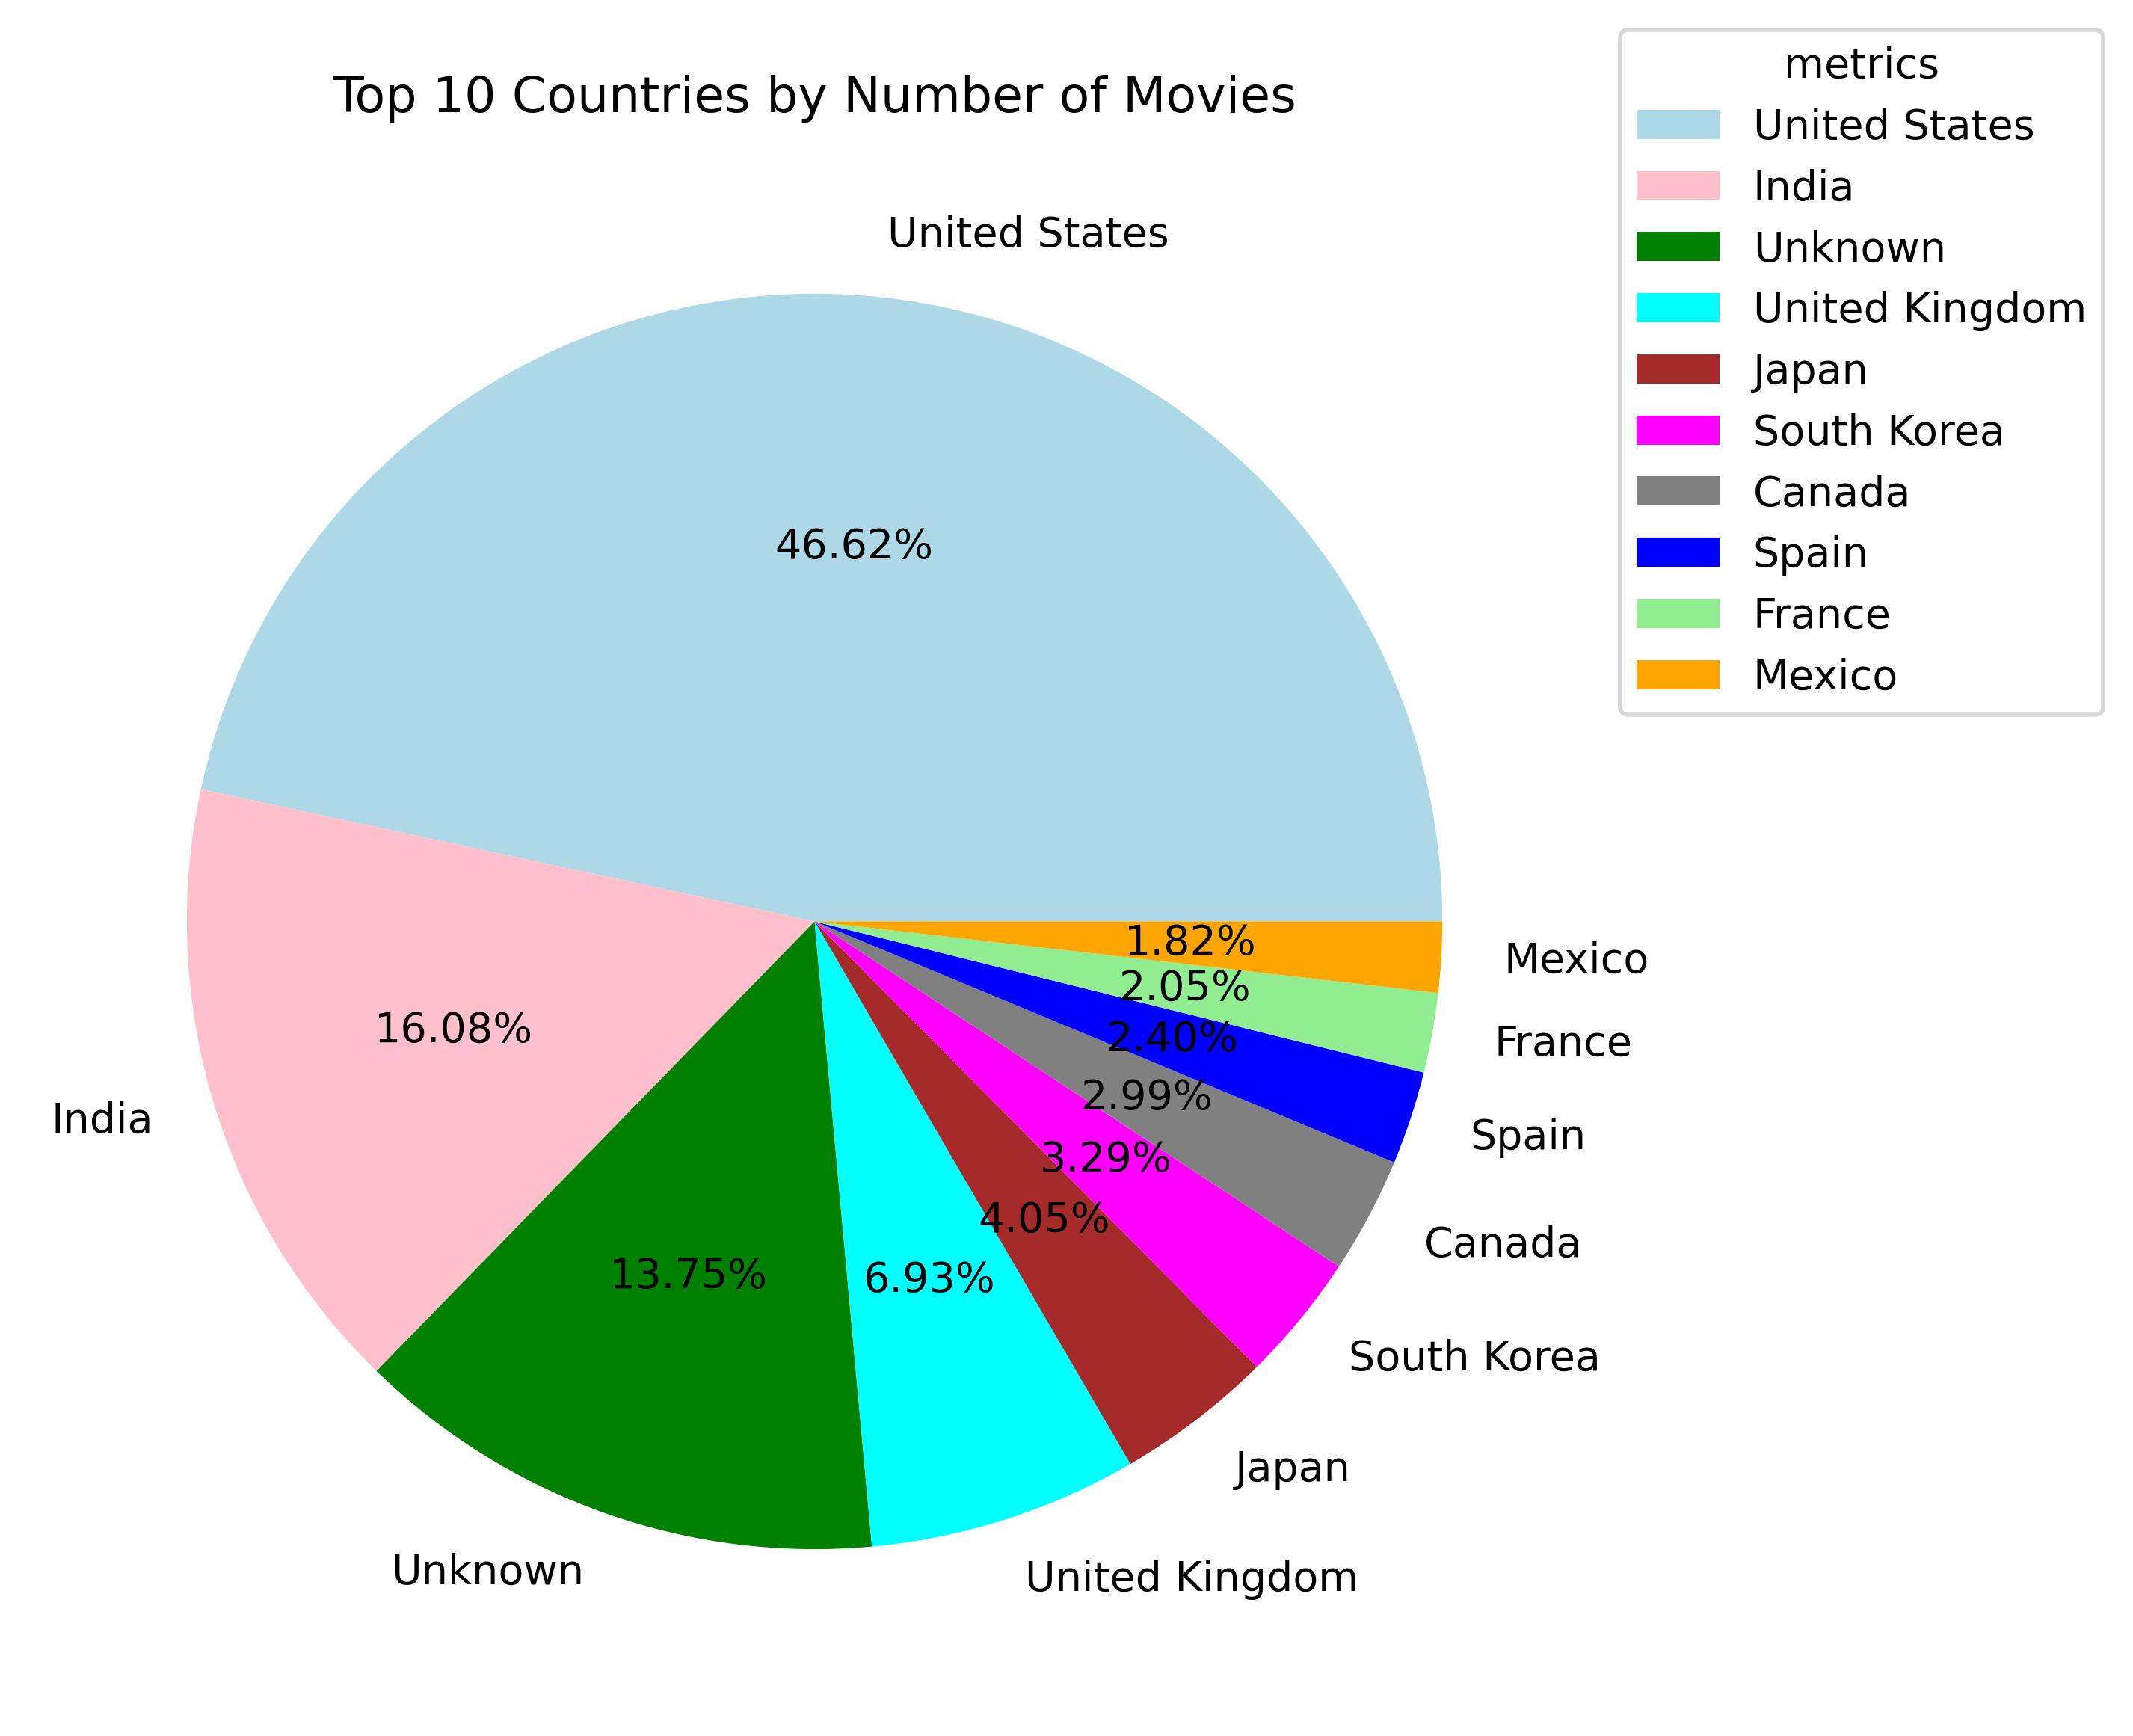

In [153]:
top_countries =df['country'].value_counts().head(10)

labels = top_countries.index
sizes = top_countries.values
colors=['lightblue', 'pink','green','cyan','brown','magenta','gray', 'blue','lightgreen','orange']

plt.figure(figsize=(10,6),dpi=400)
plt.pie(sizes,
       labels=labels,
       autopct="%.2f%%",
       colors=colors)
plt.title('Top 10 Countries by Number of Movies')
plt.legend(title='metrics',loc='center left', bbox_to_anchor=(1, 0.85))
plt.tight_layout()

plt.show()

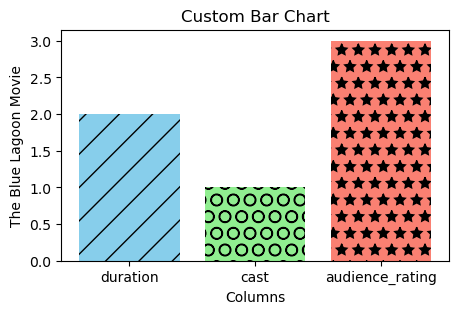

In [157]:
labels = ['duration', 'cast', 'audience_rating']
values = [2, 1, 3] 

plt.figure(figsize=(5, 3), dpi=100)
bars = plt.bar(labels, values, color=['skyblue', 'lightgreen', 'salmon'])  


patterns = ['/', 'O', '*']
for bar, pattern in zip(bars, patterns):
    bar.set_hatch(pattern)


plt.xlabel('Columns')
plt.ylabel('The Blue Lagoon Movie')
plt.title('Custom Bar Chart')


plt.savefig('barchart.png', dpi=300, bbox_inches='tight')
plt.show()

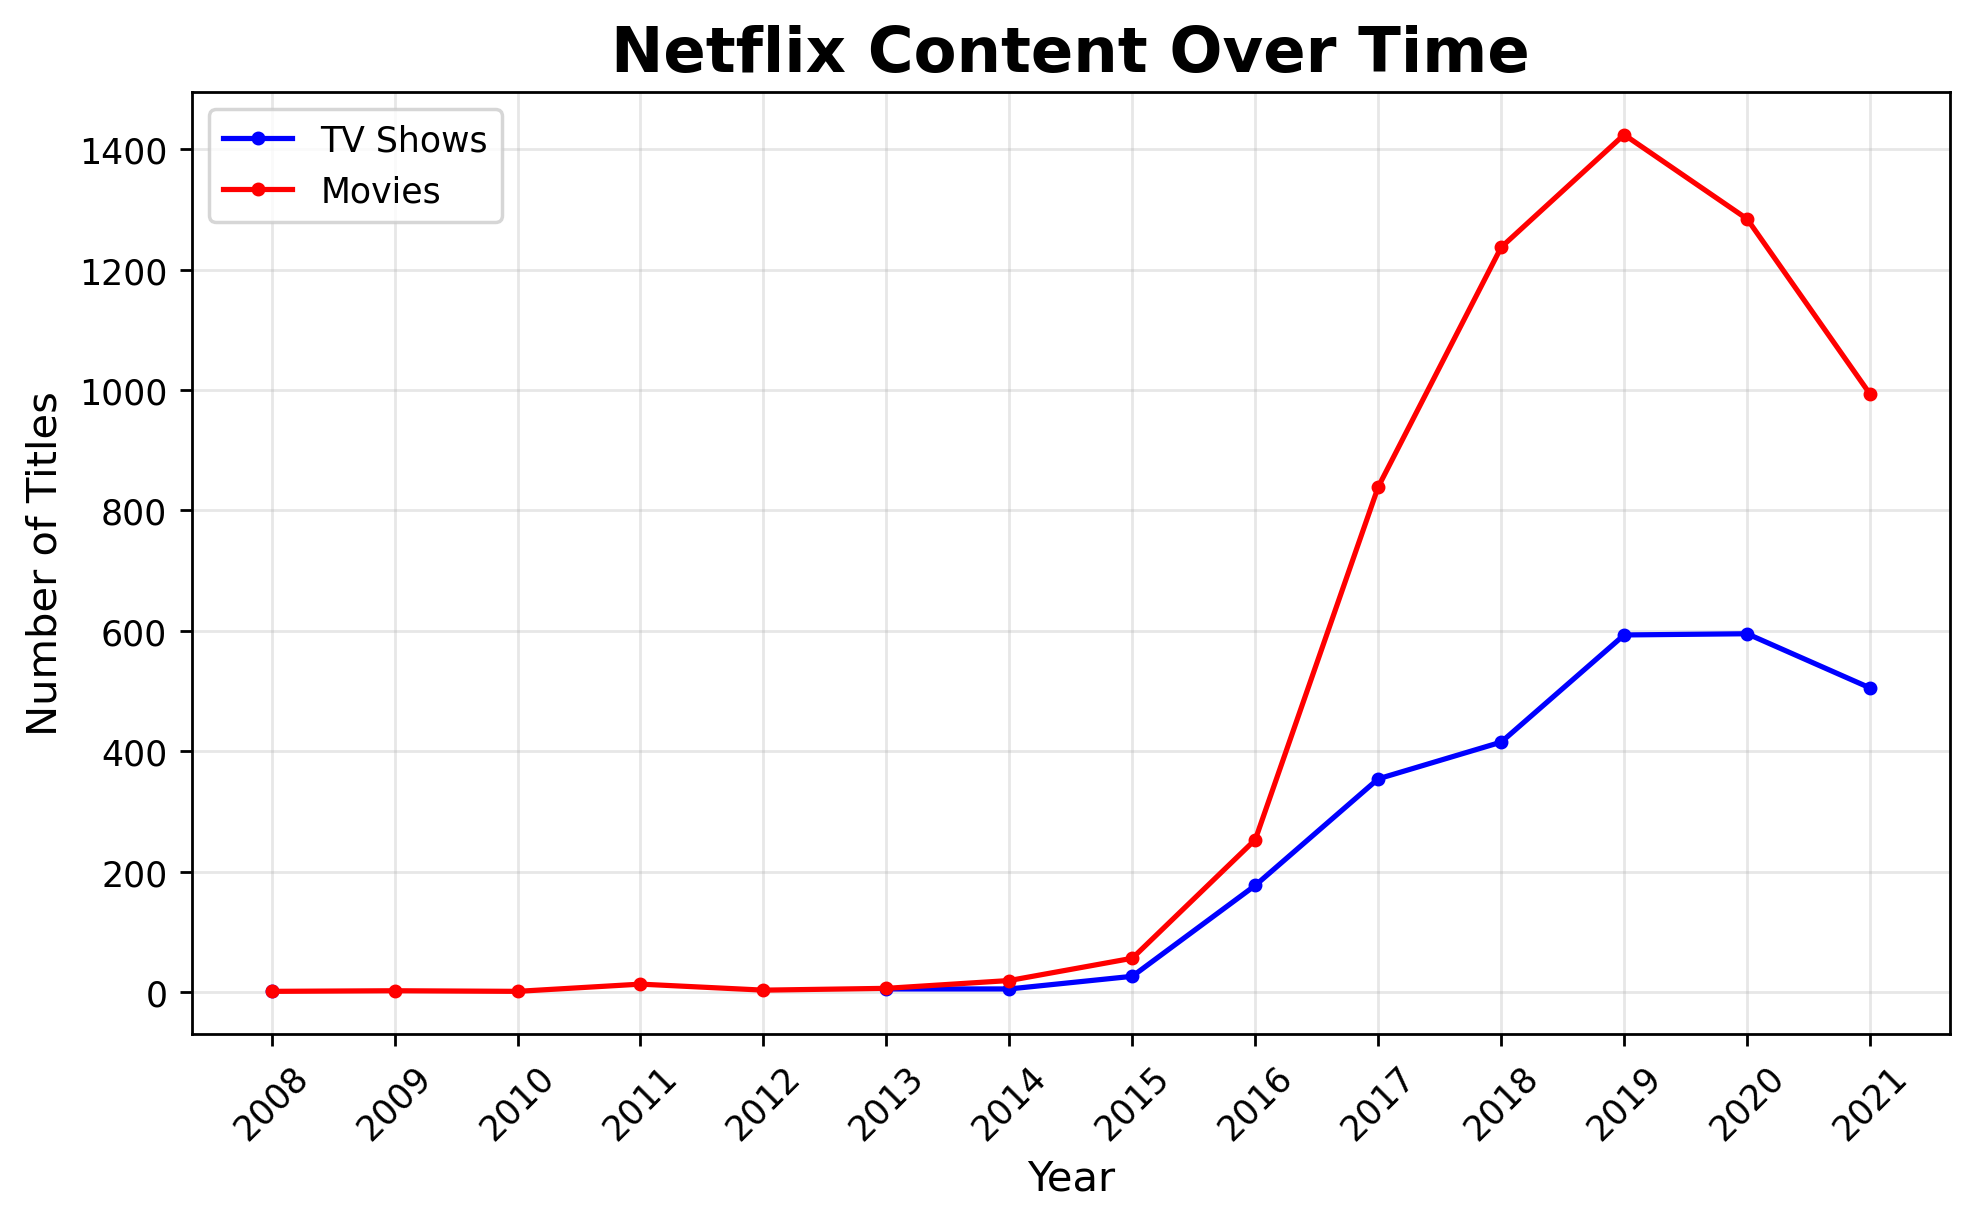

In [163]:
plt.figure(figsize=(8, 5), dpi=250)

plt.title('Netflix Content Over Time', 
          fontdict={'fontweight': 'bold', 'fontsize': 18})


plt.plot(content_by_year.index, content_by_year['TV Show'], 'b.-', label="TV Shows")
plt.plot(content_by_year.index, content_by_year['Movie'], 'r.-', label="Movies")


plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.xticks(content_by_year.index, rotation=45)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.legend()
plt.show()

After years of balance, movies surged ahead of TV shows post-2013